# Principal Component Analysis (PCA)

## Overview

Principal Component Analysis (PCA) is a statistical technique used for dimensionality reduction while preserving as much variability (information) as possible.

It transforms a set of possibly correlated variables into a new set of linearly uncorrelated variables called **Principal Components**.

These components are:

* Orthogonal (perpendicular to each other)
* Ordered by importance
* Linear combinations of original variables

## Mathematical Foundation

Let $X$ be a standardized dataset with $n$ observations and $m$ features.

The covariance matrix is defined as:

$$
C = \frac{1}{n-1} X^T X
$$

PCA is based on solving the eigenvalue problem:

$$
C v = \lambda v
$$

Where:

* $C$ = Covariance matrix
* $v$ = Eigenvector
* $\lambda$ = Eigenvalue

## Principal Components

Each eigenvector represents a **principal component direction**.

Each eigenvalue represents the **amount of variance captured** in that direction.

The first principal component maximizes: $
\text{Var}(Xv)
$

Subject to: $
||v|| = 1
$

The second principal component:

* Maximizes remaining variance
* Is orthogonal to the first

This process continues for all components.

## Explained Variance

The total variance in the dataset equals the sum of all eigenvalues:

$$
\text{Total Variance} = \sum \lambda_i
$$

The proportion of variance explained by the $i^{th}$ component is:

$$
\text{Explained Variance Ratio} = \frac{\lambda_i}{\sum \lambda}
$$

This measures the importance of each principal component.

## Key Properties

* Principal components are orthogonal.
* They are uncorrelated.
* They are ranked in decreasing order of variance.
* The first few components often capture most of the information.
* This optimization leads directly to the eigenvalue formulation of the covariance matrix.

## Advantages

* Reduces dimensionality
* Removes multicollinearity
* Improves computational efficiency
* Helps in data visualization
* Retains maximum variance

The notebook begins by importing the essential Python libraries used for data analysis and visualization.

* **NumPy** is used for numerical computations and working with arrays and mathematical operations.
* **Pandas** is used for data manipulation and handling structured datasets such as tables (DataFrames).
* **Matplotlib** is a visualization library used for creating basic plots and graphs.
* **Seaborn** is built on top of Matplotlib and provides advanced statistical visualizations with better styling.

These libraries form the foundation for performing data preprocessing, analysis, and visualization tasks in the notebook.


In [1]:
# Import Libaries required
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading Data from CSV

In this step, the dataset is loaded into the notebook using Pandas. The `read_csv` function reads the CSV file and stores it in a DataFrame named `df`. Using `df.head()` displays the first few records, allowing an initial look at the structure and columns of the data before further analysis.

The dataset used is the **Heart Disease Dataset**, which can be found here:
[Click here](https://www.kaggle.com/datasets/uciml/iris)


In [2]:
# Reading Data From CSV
df = pd.read_csv(r'C:\Users\athar\Downloads\Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Step 1: Data Cleaning and Initial Inspection

## Description

This step ensures that the dataset is clean, consistent, and ready for statistical analysis and PCA. Data quality is verified before performing any transformations.

## Key Points

* Check dataset shape (rows × columns)
* Identify missing values
* Remove duplicate records
* Verify dataset size after cleaning
* Ensure data integrity before analysis

In [3]:
# Check dataset shape before cleaning
rows, columns = df.shape
print(f"Dataset contains {rows} entries and {columns} attributes BEFORE cleaning.")

# Check missing values
print("Missing Values Before Handling:")
print(df.isnull().sum())

# Drop duplicate rows
df = df.drop_duplicates()

# Check dataset shape after cleaning
rows, columns = df.shape
print(f"Dataset contains {rows} entries and {columns} attributes AFTER cleaning.")

Dataset contains 150 entries and 6 attributes BEFORE cleaning.
Missing Values Before Handling:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Dataset contains 150 entries and 6 attributes AFTER cleaning.


# Step 2: Outlier Detection and Capping (IQR Method)

## Description

This step identifies and handles outliers using the Interquartile Range (IQR) method. Instead of removing extreme values, they are capped within calculated bounds (Winsorization) to preserve dataset size and stability.

## Key Points

* Select only numerical features
* Compute first quartile ($Q_1$) and third quartile ($Q_3$)
* Calculate Interquartile Range: $
IQR = Q_3 - Q_1
$

* Define lower and upper bounds:

$$
\text{Lower Bound} = Q_1 - 1.5 \times IQR
$$

$$
\text{Upper Bound} = Q_3 + 1.5 \times IQR
$$

* Cap values outside bounds using clipping



## Properties

* Reduces effect of extreme values
* Maintains original dataset size
* Improves reliability of mean and variance
* Prevents distortion in covariance and PCA
* Stabilizes statistical distribution


In [4]:
# Select only numerical columns for IQR calculation
num_df = df.select_dtypes(include='number')

# Calculate first quartile (Q1) and third quartile (Q3)
q1 = num_df.quantile(0.25)
q3 = num_df.quantile(0.75)

# Calculate Inter-Quartile Range (IQR)
iqr = q3 - q1
print("Inter-Quartile Range:\n", iqr)

# Calculate lower and upper bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("\nLower Bound:\n", lower_bound)
print("\nUpper Bound:\n", upper_bound)

# Cap outliers using clip (Winsorization)
new_df = df.copy()
new_df[num_df.columns] = num_df.clip(lower=lower_bound, upper=upper_bound, axis=1)

print("\nOutlier capping completed.")

Inter-Quartile Range:
 Id               74.5
SepalLengthCm     1.3
SepalWidthCm      0.5
PetalLengthCm     3.5
PetalWidthCm      1.5
dtype: float64

Lower Bound:
 Id              -73.50
SepalLengthCm     3.15
SepalWidthCm      2.05
PetalLengthCm    -3.65
PetalWidthCm     -1.95
dtype: float64

Upper Bound:
 Id               224.50
SepalLengthCm      8.35
SepalWidthCm       4.05
PetalLengthCm     10.35
PetalWidthCm       4.05
dtype: float64

Outlier capping completed.


In [5]:
# Dataset After Capping the Outliers
new_df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


# Step 3: Correlation Analysis and Redundant Feature Removal

## Description

This step identifies highly correlated numerical features and removes redundant ones to reduce multicollinearity. Strong linear relationships between variables can lead to duplicated information and unstable statistical modeling.


## Key Concept

The Pearson Correlation Coefficient is calculated as:

$$
r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$

Where:

* $\text{Cov}(X, Y)$ = Covariance between variables
* $\sigma_X$ = Standard deviation of X
* $\sigma_Y$ = Standard deviation of Y

The value of $r$ lies between $
-1 \le r \le 1
$


## Threshold Condition

If: $
|r| > 0.8
$

Then the features are considered highly correlated.

One of them is removed to eliminate redundancy.


## Key Points

* Select only numerical features
* Remove zero-variance columns (constant features)
* Remove low-unique columns (categorical-like data)
* Compute pairwise correlation
* Drop features exceeding threshold
* Update dataset after removal


## Properties

* Reduces multicollinearity
* Eliminates redundant information
* Improves model stability
* Prevents overfitting in regression models
* Simplifies feature space

In [52]:
threshold = 0.8
columns_to_drop = set()

# Select numeric columns
numeric_columns = new_df.select_dtypes(include=[np.number]).columns

# Remove columns with zero variance
numeric_columns = [col for col in numeric_columns if new_df[col].std() != 0]

# Remove low unique columns (categorical-like)
numeric_columns = [col for col in numeric_columns if new_df[col].nunique() > 5]

for i in range(len(numeric_columns)):
    for j in range(i):
        col1 = numeric_columns[i]
        col2 = numeric_columns[j]

        correlation = new_df[col1].corr(new_df[col2])

        print(f"Checking {col1} vs {col2} → Correlation: {correlation:.2f}")

        if abs(correlation) > threshold:
            print(f"High correlation detected. Removing {col1}")
            columns_to_drop.add(col1)

new_df = new_df.drop(columns=columns_to_drop)

print("\nRemoved Columns:", list(columns_to_drop))
print("Remaining Columns:", list(new_df.columns))

Checking SepalWidthCm vs SepalLengthCm → Correlation: -0.11

Removed Columns: []
Remaining Columns: ['SepalLengthCm', 'SepalWidthCm', 'Species']


# Step 4: Feature Selection for Analysis

## Description
This step prepares the dataset for statistical modeling and PCA by separating input features from the target variable.

## Key Points

- The `Id` column is removed as it does not carry analytical value.
- Categorical attributes (e.g., `Species`) are separated from numerical features.
- The feature matrix $X$ contains only numerical variables.
- The target variable $y$ stores class labels for supervised analysis.

## Purpose

- Ensures only meaningful numerical data is used for PCA.
- Prevents non-numeric variables from affecting covariance calculations.
- Maintains a clean separation between features and target.

In [16]:
# Removing Id Column
new_df = new_df.drop(columns=['Id'], errors='ignore')

# Droping Categorical type of attributes
X = new_df.drop(columns=['Species'])
y = new_df['Species']

In [17]:
# Dataset after Z-score standardization
new_df.head(10)

,SepalLengthCm,SepalWidthCm,Species
0,-0.897674,1.062164,Iris-setosa
1,-1.139200,-0.119769,Iris-setosa
2,-1.380727,0.353004,Iris-setosa
3,-1.501490,0.116617,Iris-setosa
4,-1.018437,1.298550,Iris-setosa
5,-0.535384,2.007710,Iris-setosa
6,-1.501490,0.825777,Iris-setosa
7,-1.018437,0.825777,Iris-setosa
8,-1.743017,-0.356156,Iris-setosa
9,-1.139200,0.116617,Iris-setosa


# Step 5: Z-Score Normalization

## Description
This step standardizes numerical features so that each variable has a mean of 0 and a standard deviation of 1. This ensures fair contribution of all features in PCA.

## Formula

$$
z = \frac{x - \mu}{\sigma}
$$

Where:

- $x$ = Original value  
- $\mu$ = Mean of the feature  
- $\sigma$ = Standard deviation  

## Key Points

- Applied only to selected numerical features  
- Removes scale differences between variables  
- Ensures variance-based methods (like PCA) are not biased  
- Produces standardized feature matrix $X_{scaled}$  

## Purpose

- Makes features comparable  
- Stabilizes covariance computation  
- Prepares data for principal component extraction  

In [38]:
# Apply Z-score normalization manually
features = ['SepalLengthCm','SepalWidthCm']

for col in features:
    mean = new_df[col].mean()
    std = new_df[col].std()
    new_df[col] = (new_df[col] - mean) / std

X_scaled = new_df[features].values

print("Z-score normalization applied.")
print(f"X_scaled: {X_scaled}")

Z-score normalization applied.
X_scaled: [[-0.89767388  1.06216386]
 [-1.13920048 -0.11976922]
 [-1.38072709  0.35300401]
 [-1.50149039  0.1166174 ]
 [-1.01843718  1.29855048]
 [-0.53538397  2.00771032]
 [-1.50149039  0.82577724]
 [-1.01843718  0.82577724]
 [-1.74301699 -0.35615583]
 [-1.13920048  0.1166174 ]
 [-0.53538397  1.53493709]
 [-1.25996379  0.82577724]
 [-1.25996379 -0.11976922]
 [-1.8637803  -0.11976922]
 [-0.05233076  2.24409694]
 [-0.17309407  2.36229025]
 [-0.53538397  2.00771032]
 [-0.89767388  1.06216386]
 [-0.17309407  1.77132371]
 [-0.89767388  1.77132371]
 [-0.53538397  0.82577724]
 [-0.89767388  1.53493709]
 [-1.50149039  1.29855048]
 [-0.89767388  0.58939063]
 [-1.25996379  0.82577724]
 [-1.01843718 -0.11976922]
 [-1.01843718  0.82577724]
 [-0.77691058  1.06216386]
 [-0.77691058  0.82577724]
 [-1.38072709  0.35300401]
 [-1.25996379  0.1166174 ]
 [-0.53538397  0.82577724]
 [-0.77691058  2.36229025]
 [-0.41462067  2.36229025]
 [-1.13920048  0.1166174 ]
 [-1.01843718 

# Step 6: Manual Covariance Matrix Computation

## Description
This step computes the covariance matrix manually using the standardized feature matrix. The covariance matrix measures how pairs of variables vary together.

## Formula

For two variables $X$ and $Y$:

$$
\text{Cov}(X, Y) = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{n - 1}
$$

Matrix form: $
C = \frac{1}{n-1} X^T X
$

## Key Points

- Uses standardized feature matrix $X_{scaled}$  
- Computes pairwise covariance for all features  
- Diagonal elements represent variances  
- Off-diagonal elements represent covariances  

## Purpose

- Captures relationships between features  
- Forms the foundation for eigen decomposition  
- Essential for extracting principal components  

In [40]:
X = X_scaled   # standardized
n = X.shape[0]
m = X.shape[1]

# Mean (just in case)
mean = np.mean(X, axis=0)

# Initialize matrix
cov_matrix = np.zeros((m, m))

for i in range(m):
    for j in range(m):
        sum_value = 0
        for k in range(n):
            sum_value += (X[k, i] - mean[i]) * (X[k, j] - mean[j])
        cov_matrix[i, j] = sum_value / (n - 1)

print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.         -0.11034275]
 [-0.11034275  1.        ]]


# Step 7: Eigen Decomposition of Covariance Matrix

## Description
This step performs eigen decomposition on the covariance matrix to extract principal directions and their corresponding variances.

## Eigenvalue Equation

$$
C v = \lambda v
$$

Where:

- $C$ = Covariance matrix  
- $v$ = Eigenvector (principal direction)  
- $\lambda$ = Eigenvalue (variance captured in that direction)  

## Key Points

- Eigenvectors define new orthogonal axes (principal components)  
- Eigenvalues indicate the amount of variance captured  
- Larger eigenvalues represent more important components  
- Components are later sorted in descending order of variance  

## Purpose

- Identifies directions of maximum variance  
- Enables dimensionality reduction  
- Forms the mathematical foundation of PCA  

In [41]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [1.11034275 0.88965725]
Eigenvectors:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


# Step 8: Sorting Eigenvalues and Eigenvectors

## Description
This step sorts the eigenvalues in descending order and rearranges the corresponding eigenvectors accordingly. This ensures that principal components are ranked from most important to least important.

## Concept

Eigenvalues represent variance captured by each component.

To prioritize components:

$$
\lambda_1 \ge \lambda_2 \ge \lambda_3 \ge \dots
$$

Eigenvectors must be reordered to match the sorted eigenvalues.

## Key Points

- Sort eigenvalues in descending order  
- Reorder eigenvectors using the same index  
- Ensure correct pairing between eigenvalues and eigenvectors  
- Maintain proper ranking of principal components  

## Purpose

- Identifies most informative components first  
- Prepares for explained variance calculation  
- Enables correct dimensionality reduction  

In [42]:
sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

print("Sorted Eigenvalues:", sorted_eigenvalues)

Sorted Eigenvalues: [1.11034275 0.88965725]


# Step 9: Explained Variance and Principal Components

## Description
This step calculates how much total variance each principal component captures and determines their cumulative contribution.

## Explained Variance Ratio

Each eigenvalue represents variance captured by a principal component.

$$
\text{Explained Variance Ratio} = \frac{\lambda_i}{\sum \lambda}
$$

Where:

- $\lambda_i$ = Eigenvalue of the $i^{th}$ principal component  
- $\sum \lambda$ = Total variance in the dataset  

The cumulative variance is:

$$
\text{Cumulative Variance} = \sum_{i=1}^{k} \frac{\lambda_i}{\sum \lambda}
$$


## Understanding PC1 and PC2

### PC1 (First Principal Component)

- Captures the **maximum variance** in the dataset  
- Represents the most informative direction  
- Explains the largest percentage of total variability  

$$
\lambda_1 = \text{Maximum variance direction}
$$


### PC2 (Second Principal Component)

- Captures the **second highest variance**  
- Is orthogonal (perpendicular) to PC1  
- Explains remaining variability not captured by PC1  

$$
v_1 \perp v_2
$$

## Key Points

- PC1 always explains more variance than PC2  
- The sum of all explained variance ratios equals 1  
- If cumulative variance is high with fewer PCs, dimensionality reduction is effective  

## Purpose

- Determines importance of each principal component  
- Helps decide how many components to retain  
- Measures information preservation after reduction  

In [46]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
print("Explained Variance Ratio:", explained_variance)
cumulative_variance = np.cumsum(explained_variance)
print("Cumulative Variance:", cumulative_variance)

Explained Variance Ratio: [0.55517138 0.44482862]
Cumulative Variance: [0.55517138 1.        ]


# Step 10: Projection onto Principal Components

## Description
This step reduces the dataset by projecting the standardized feature matrix onto the top $k$ principal components.

## Projection Formula

$$
X_{PCA} = X_{scaled} \cdot W
$$

Where:

- $X_{scaled}$ = Standardized feature matrix  
- $W$ = Matrix containing the first $k$ eigenvectors  
- $X_{PCA}$$ = Transformed lower-dimensional dataset  


## Understanding the Components

### PC1
- Captures maximum variance in the data  
- Represents the most important direction  
- Contains the highest information content  

### PC2
- Captures the second highest variance  
- Is orthogonal to PC1  
- Represents remaining independent information  


## Key Points

- $k = 2$ selects the first two principal components  
- The new dataset shape becomes $(n \times k)$  
- Dimensionality is reduced while preserving maximum variance  
- Original correlated features become uncorrelated components  

## Purpose

- Compresses data into fewer dimensions  
- Retains maximum information  
- Enables visualization in 2D space  
- Improves computational efficiency  

In [44]:
k = 2
W = sorted_eigenvectors[:, :k]
X_pca = np.dot(X_scaled, W)
print(X_pca[:5])

[[-1.38581456  0.11631198]
 [-0.72084676 -0.89022601]
 [-1.22593302 -0.72670996]
 [-1.14417499 -0.97925308]
 [-1.63835768  0.19807001]]


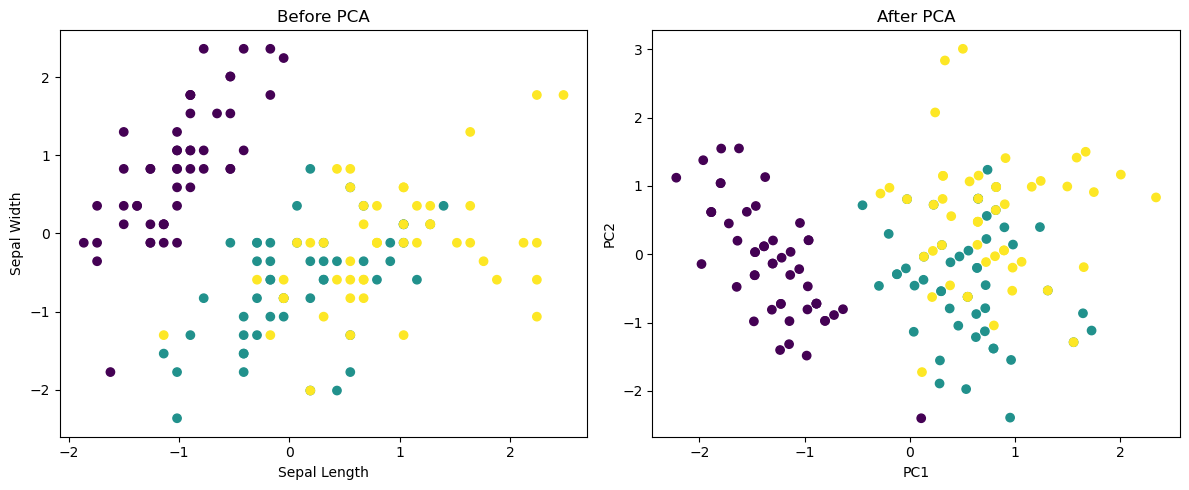

In [45]:
plt.figure(figsize=(12,5))

# Before PCA
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=pd.factorize(y)[0])
plt.title("Before PCA")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

# After PCA
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=pd.factorize(y)[0])
plt.title("After PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()